<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/FinalProjectPt3rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
df = pd.read_csv('/content/drive/MyDrive/stock_prepared.csv')

In [3]:
print(df.shape)
df.head()

(20860334, 31)


,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,...,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_TRANSPORTATION,sector_nan
0,A,33.172390,32.859444,28.705677,32.501789,33.708870,3708000,1999-12-17,-0.938839,-0.027778,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A,33.082977,33.530045,29.291510,32.993561,33.574749,1196800,1999-12-20,0.670601,0.020408,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,33.395924,33.351215,29.135279,32.904148,33.395924,2259400,1999-12-21,-0.178829,-0.005333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,33.351215,34.021816,29.721119,33.127682,34.021816,1905700,1999-12-22,0.670601,0.020107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,33.977112,35.586552,31.088053,33.932404,35.765381,2159400,1999-12-23,1.564735,0.045992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df = df.sort_values(['ticker', 'date'])

df['ema_12'] = (
    df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
)

df['ema_26'] = (
    df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
)

In [5]:
df['macd'] = df['ema_12'] - df['ema_26']

df['macd_signal_line'] = (
    df.groupby('ticker')['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
)

In [6]:
previous_macd = df.groupby('ticker')['macd'].shift(1)
previous_signal = df.groupby('ticker')['macd_signal_line'].shift(1)

df['macd_signal'] = 'Hold'

buy_condition = (
    (previous_macd <= previous_signal) & (df['macd'] > df['macd_signal_line'])
)

sell_condition = (
    (previous_macd >= previous_signal) & (df['macd'] < df['macd_signal_line'])
)

df.loc[buy_condition, 'macd_signal'] = 'Buy'
df.loc[sell_condition, 'macd_signal'] = 'Sell'

In [7]:
df['price_diff'] = (
    df.groupby('ticker')['close'].diff()
)

df['gain'] = df['price_diff'].clip(lower=0)
df['loss'] = df['price_diff'].clip(upper=0)

In [8]:
avg_gain = (
    df.groupby('ticker')['gain'].transform(lambda x: x.ewm(span=14, adjust=False).mean())
)

avg_loss = (
    df.groupby('ticker')['loss'].transform(lambda x: x.ewm(span=14, adjust=False).mean())
)

In [9]:
rs = avg_gain / avg_loss

In [10]:
df['rsi'] = 100 - (100 / (1 + rs))

In [11]:
df['rsi_signal'] = 'Hold'

df.loc[df['rsi'] < 30, 'rsi_signal'] = 'Buy'
df.loc[df['rsi'] > 70, 'rsi_signal'] = 'Sell'

In [12]:
df['trading_signal'] = 'Hold'

buy_condition = (
    (df['macd_signal'] == 'Buy') & (df['rsi_signal'] == 'Buy')
)

sell_condition = (
    (df['macd_signal'] == 'Sell') & (df['rsi_signal'] == 'Sell')
)

df.loc[buy_condition, 'trading_signal'] = 'Buy'
df.loc[sell_condition, 'trading_signal'] = 'Sell'

In [13]:
df['trading_signal'].value_counts()

,count
trading_signal,
Hold,20501126
Sell,205930
Buy,153278


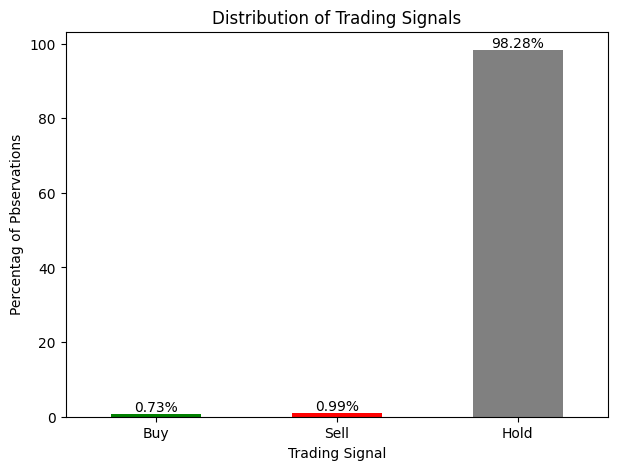

In [14]:
signal_percent = (
    df['trading_signal'].value_counts(normalize=True).reindex(['Buy', 'Sell', 'Hold'], fill_value=0) * 100
)

ax = signal_percent.plot(
    kind='bar',
    figsize=(7, 5),
    color=['green', 'red', 'gray']
)

plt.title('Distribution of Trading Signals')
plt.xlabel('Trading Signal')
plt.ylabel('Percentag of Pbservations')
plt.xticks(rotation=0)

for i, value in enumerate(signal_percent):
    ax.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

In [15]:
feature_columns = [
    'daily_return',
    'close_lag_1',
    'ma5',
    'ma20',
    'volatility_20',
    'daily_range_pct'

]

In [16]:
model_df = df.dropna(
    subset=feature_columns + ['trading_signal']
).copy()

print('Model dataset: ', model_df.shape)

Model dataset:  (20860334, 42)


In [17]:
label_encoder = LabelEncoder()
model_df['target'] = label_encoder.fit_transform(model_df['trading_signal'])

print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

{'Buy': np.int64(0), 'Hold': np.int64(1), 'Sell': np.int64(2)}


In [18]:
unique_dates = np.sort(model_df['date'].unique())

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index]

train_df = model_df[
    model_df['date'] < train_end_date
].copy()

test_df = model_df[
    model_df['date'] >= train_end_date
].copy()


print('Training: ', train_df.shape)
print('Testing: ', test_df.shape)

print(
    'Train period: ',
    train_df['date'].min(),
    ' to ',
    train_df['date'].max()
)

print(
    'Test period: ',
    test_df['date'].min(),
    ' to ',
    test_df['date'].max()
)

Training:  (10692900, 43)
Testing:  (10167434, 43)
Train period:  1970-01-30  to  2008-11-28
Test period:  2008-12-01  to  2018-08-24


In [19]:
X_train = train_df[feature_columns]
y_train = train_df['target']

X_test = test_df[feature_columns]
y_test = test_df['target']

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
print(X_train_scaled.shape)

(10692900, 6)


In [22]:
sample_size = min(300_000, len(X_train_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_train_scaled),
    size=sample_size,
    replace=False
)

In [23]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{name} Performance:')
    print(f'Accuracy:  {acc:.8f}')
    print(f'Precision: {prec:.8f}')
    print(f'Recall:    {rec:.8f}')
    print(f'F1-Score:  {f1:.8f}')

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }

In [24]:
def plot_confusion_matrix(model_name, y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    plt.figure(figsize=(6, 5))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

In [25]:
lr = LogisticRegression(max_iter=sample_size)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_results = evaluate_model('Logistic Regression', y_test, lr_pred)


Logistic Regression Performance:
Accuracy:  0.98280835
Precision: 0.96591512
Recall:    0.98280835
F1-Score:  0.97428851


In [26]:
'''
Reduced n_estimators and max_depth to reduce loading time
and used a smaller sample size i.e. the sample_indices) to greatly reduce loading time
 (took over an hour for with regular X_test and n_estimators=300 and max_depth=None)
'''
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    max_samples=0.8
)
rf.fit(X_train.iloc[sample_indices], y_train.iloc[sample_indices])
rf_pred = rf.predict(X_test)

rf_results = evaluate_model('Random Forest', y_test, rf_pred)


Random Forest Performance:
Accuracy:  0.98280972
Precision: 0.96591514
Recall:    0.98280972
F1-Score:  0.97428920


In [27]:
svm = LinearSVC()
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

svm_results = evaluate_model('Linear SVM', y_test, svm_pred)


Linear SVM Performance:
Accuracy:  0.98280982
Precision: 0.96591515
Recall:    0.98280982
F1-Score:  0.97428925


In [28]:
results_df = pd.DataFrame([lr_results, rf_results, svm_results])

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.982808,0.965915,0.982808,0.974289
1,Random Forest,0.982810,0.965915,0.982810,0.974289
2,Linear SVM,0.982810,0.965915,0.982810,0.974289


In [29]:
label_names = label_encoder.classes_
print(label_names)

['Buy' 'Hold' 'Sell']


<Figure size 600x500 with 0 Axes>

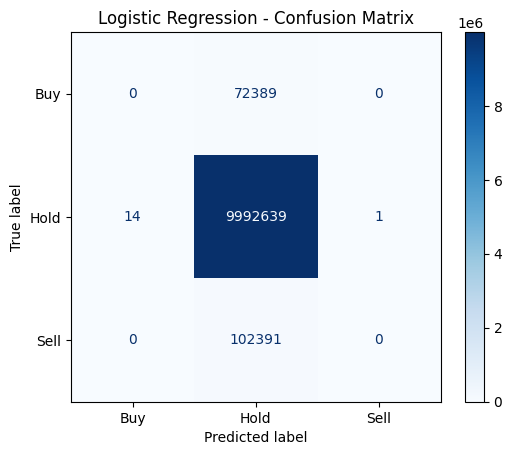

In [30]:
plot_confusion_matrix(
    'Logistic Regression',
    y_test,
    lr_pred,
    label_names
)

<Figure size 600x500 with 0 Axes>

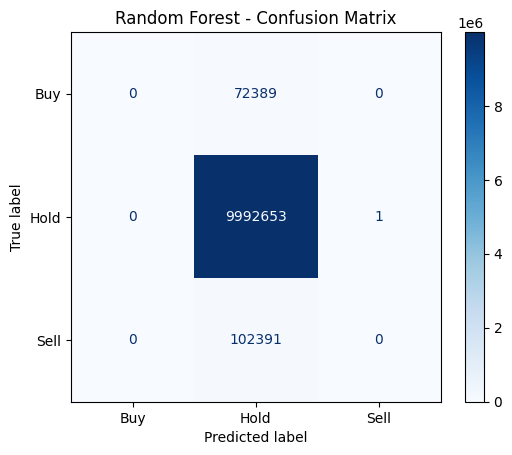

In [31]:
plot_confusion_matrix(
    'Random Forest',
    y_test,
    rf_pred,
    label_names
)

<Figure size 600x500 with 0 Axes>

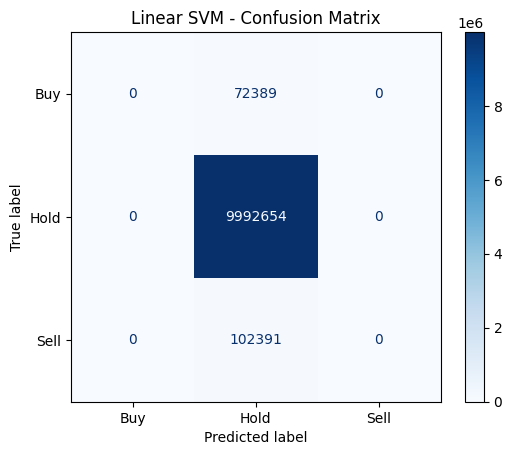

In [32]:
plot_confusion_matrix(
    'Linear SVM',
    y_test,
    svm_pred,
    label_names
)

In [33]:
# part 7 improve a model

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_results = evaluate_model('Random Forest', y_test, rf_pred)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 29.8min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 32.3min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    8.5s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:   37.6s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:   40.7s finished



Random Forest Performance:
Accuracy:  0.98280982
Precision: 0.96591515
Recall:    0.98280982
F1-Score:  0.97428925


<Figure size 600x500 with 0 Axes>

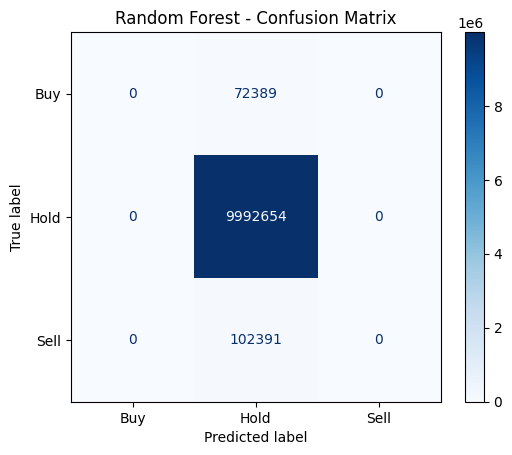

In [34]:
plot_confusion_matrix(
    'Random Forest',
    y_test,
    rf_pred,
    label_names
)